[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lanzlagman/intro-python-astro-PUP/blob/main/solutions/04_data_visualization_astronomy.ipynb)

> **Solutions copy.** Every **YOUR TURN** cell below is already filled in. Work through `notebooks/` first; read this afterwards.

# Notebook 04: Data Visualization in Astronomy and Astrophysics

**Computational and Data-driven Astrophysics: A Practical Python Workshop**
PUP Physics Society · 15 August 2026

---

You have data from an archive (NB02) and data from a simulation (NB03). This notebook is the
step everyone underestimates: **turning either one into a figure that survives a thesis
defence.**

The distinction that matters is not "pretty vs ugly". It is:

> **a plot** shows you what you already know · **a figure** makes an argument

## Part 0: Setup and data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
import pandas as pd

RAW = "https://raw.githubusercontent.com/lanzlagman/intro-python-astro-PUP/main/data/"


def load_workshop_data(filename):
    """Local file first, then GitHub. Works identically in Colab and locally."""
    for path in (f"data/{filename}", f"../data/{filename}"):
        if os.path.exists(path):
            print(f"loaded from disk: {path}")
            return pd.read_csv(path)
    print(f"downloading {filename} from GitHub")
    return pd.read_csv(RAW + filename)


# Prefer the file Notebook 02 saved; otherwise fall back to the shipped cache.
import os
if os.path.exists("data/pleiades_query_result.csv"):
    stars = pd.read_csv("data/pleiades_query_result.csv")
    print("using the file you created in Notebook 02")
else:
    stars = load_workshop_data("gaia_pleiades.csv")
    stars = stars[(stars["parallax_over_error"] > 5) & (stars["ruwe"] < 1.4)].copy()

print(f"{len(stars)} stars in the field")

using the file you created in Notebook 02
5180 stars in the field


---
## Part 1: Figure anatomy: `fig, ax`, never bare `plt.plot`

Most tutorials teach `plt.plot(x, y)`. It works, and it is a trap: it draws on whatever
figure happens to be "current", which stops making sense the moment you want two panels,
an inset, or a saved file at a specific size.

The professional idiom names its objects:

```python
fig, ax = plt.subplots()    # fig = the page,  ax = one set of axes on it
ax.plot(x, y)               # draw on THAT axes, explicitly
```

`fig` is the paper. `ax` is a panel. Everything you adjust hangs off one or the other.

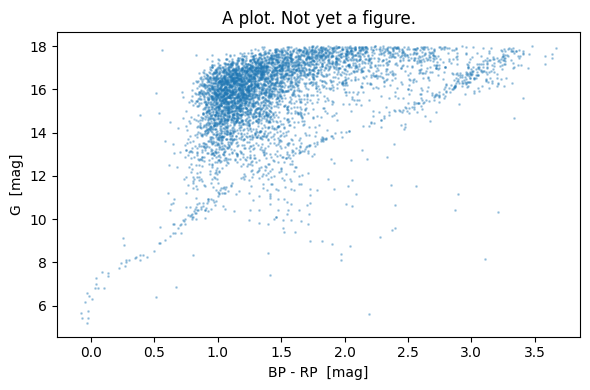

Everything is here and nothing is legible. Part 4 is where we fix it.


In [2]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(stars["bp_rp"], stars["phot_g_mean_mag"], s=1, alpha=0.3)
ax.set_xlabel("BP - RP  [mag]")
ax.set_ylabel("G  [mag]")
ax.set_title("A plot. Not yet a figure.")

plt.tight_layout(); plt.show()

print("Everything is here and nothing is legible. Part 4 is where we fix it.")

---
## Part 2: The colour–magnitude diagram

Determining the effective temperature of every member of a cluster by detailed spectral analysis is slow. Measuring colour indices is fast. With an apparent magnitude and a colour index per star you can build a **colour–magnitude diagram**, and that is what we do here.

Gaia's $BP-RP$ is the modern $B-V$: brightness through a blue filter minus brightness through
a red one. Small = hot and blue. Large = cool and red.

> **Why the y-axis is upside down.** The magnitude scale runs backwards: larger magnitude
> means fainter. Astronomers invert the axis so that *up* means *brighter*, matching physical
> intuition. It is not a stylistic choice: a CMD plotted the other way up is simply wrong, and
> every astronomer in the room will notice within one second.

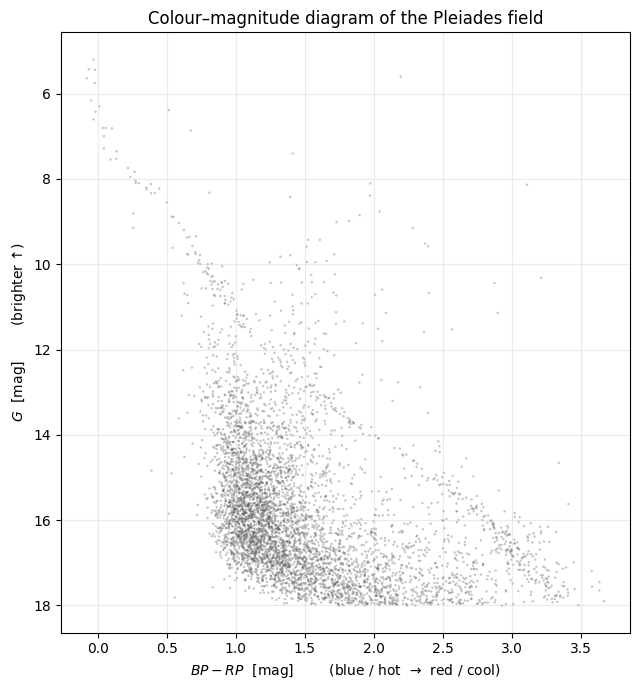

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 7))

ax.scatter(stars["bp_rp"], stars["phot_g_mean_mag"],
           s=3, alpha=0.35, color="0.35", edgecolors="none")

ax.invert_yaxis()                         # <-- brighter = up
ax.set_xlabel("$BP - RP$  [mag]        (blue / hot  →  red / cool)")
ax.set_ylabel("$G$  [mag]        (brighter ↑)")
ax.set_title("Colour–magnitude diagram of the Pleiades field")
ax.grid(alpha=0.25)

plt.tight_layout(); plt.show()

> **What is the diagonal band?** The **main sequence**, where stars burning hydrogen in their
> cores spend ~90% of their lives. Position along it is set almost entirely by mass.
>
> The scatter around it is the problem this workshop keeps circling: most of these stars are
> *not in the cluster*. They are foreground and background objects at different distances,
> which smears the sequence out.

### From the observer's diagram to the theorist's

Two H–R diagrams get conflated for years:

- **the observer's**: apparent or absolute magnitude against colour. Built from things a
  telescope measures.
- **the theorist's**: luminosity against effective temperature. Built from things a stellar
  model predicts.

Converting between them is the job of the **distance modulus** you wrote in Notebook 01.
Here it is again, doing real work.

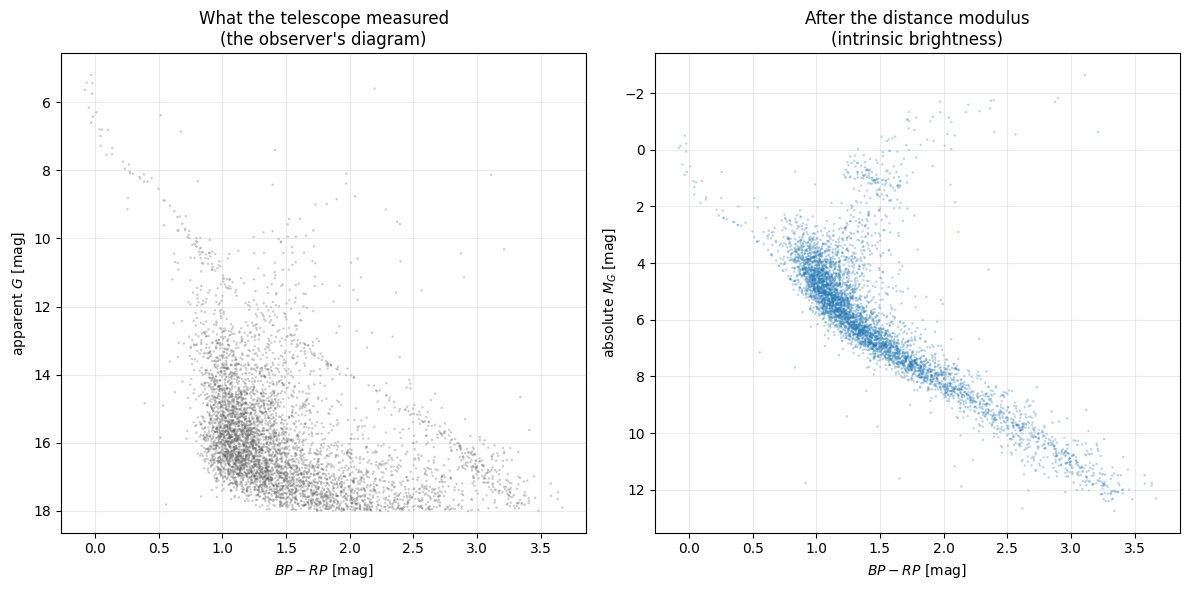

In [4]:
# The distance modulus, exactly as written in Notebook 01
distance_pc = 1000.0 / stars["parallax"]
stars["M_G"] = stars["phot_g_mean_mag"] - 5 * np.log10(distance_pc) + 5

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True)

axes[0].scatter(stars["bp_rp"], stars["phot_g_mean_mag"],
                s=3, alpha=0.3, color="0.35", edgecolors="none")
axes[0].invert_yaxis()
axes[0].set_ylabel("apparent $G$ [mag]")
axes[0].set_title("What the telescope measured\n(the observer's diagram)")

axes[1].scatter(stars["bp_rp"], stars["M_G"],
                s=3, alpha=0.3, color="tab:blue", edgecolors="none")
axes[1].invert_yaxis()
axes[1].set_ylabel("absolute $M_G$ [mag]")
axes[1].set_title("After the distance modulus\n(intrinsic brightness)")

for ax in axes:
    ax.set_xlabel("$BP - RP$ [mag]")
    ax.grid(alpha=0.25)

plt.tight_layout(); plt.show()

# print("One equation from Notebook 01 moved us from 'how bright it looks'")
# print("to 'how bright it is'. That is the whole distance ladder in one line.")

---
## Part 3: The proper-motion diagram, and the moment the cluster appears

Cluster members share a **common origin**, which has an observational consequence Gaia has
made routine: they share a **common velocity through space**.

Projected on the sky, that velocity is the **proper motion** $(\mu_\alpha, \mu_\delta)$. Field
stars point every which way. Cluster members all point the same way.

A scatter plot of $\mu_\alpha$ against $\mu_\delta$ is called a **vector point diagram**.

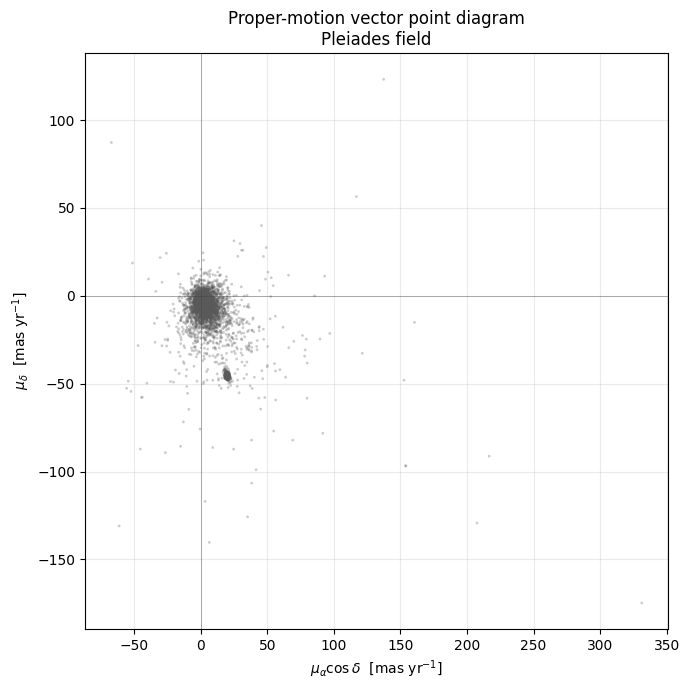

In [5]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(stars["pmra"], stars["pmdec"],
           s=4, alpha=0.3, color="0.35", edgecolors="none")

ax.set_xlabel(r"$\mu_\alpha \cos\delta$  [mas yr$^{-1}$]")
ax.set_ylabel(r"$\mu_\delta$  [mas yr$^{-1}$]")
ax.set_title("Proper-motion vector point diagram\nPleiades field")
ax.axhline(0, color="k", lw=0.5, alpha=0.4)
ax.axvline(0, color="k", lw=0.5, alpha=0.4)
ax.grid(alpha=0.25)

plt.tight_layout(); plt.show()

> **There it is.** A dense knot, well away from the origin, sitting in a broad cloud of field
> stars scattered around zero.
>
> That knot is the Pleiades: several hundred stars that formed together about 100 million
> years ago and are still moving together. Nothing in the code knew that.
>
> **This is the actual skill.** Not `scatter()`. Knowing which two of fifteen columns to put on
> the axes.

### ✏️ YOUR TURN

Zoom in on the clump. Set the axis limits to roughly $\mu_\alpha \in [10, 30]$ and
$\mu_\delta \in [-55, -35]$ and see how tight it really is.

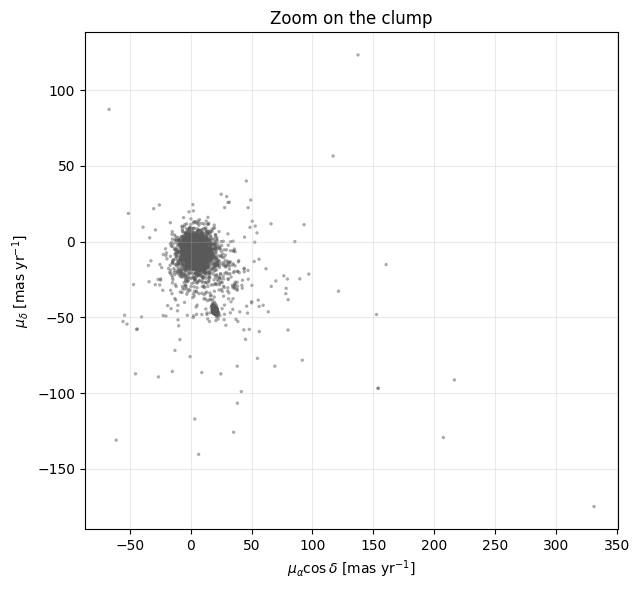

For reference, the median proper motion of the whole field is
  pmra  = 2.9 mas/yr
  pmdec = -5.2 mas/yr


In [6]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(stars["pmra"], stars["pmdec"], s=6, alpha=0.5,
           color="0.35", edgecolors="none")

ax.set_xlim(10, 30)
ax.set_ylim(-55, -35)

ax.set_xlabel(r"$\mu_\alpha \cos\delta$ [mas yr$^{-1}$]")
ax.set_ylabel(r"$\mu_\delta$ [mas yr$^{-1}$]")
ax.set_title("Zoom on the clump")
ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

print(f"For reference, the median proper motion of the whole field is")
print(f"  pmra  = {stars['pmra'].median():.1f} mas/yr")
print(f"  pmdec = {stars['pmdec'].median():.1f} mas/yr")


---
## Part 4: When a scatter plot runs out of road

Same data as Part 1, and nothing is wrong with `scatter`. It simply has an operating range,
and this dataset is past the end of it.

A scatter plot encodes **one star as one mark**. That is an honest encoding right up until the
marks stop being distinguishable from each other. Past that point the picture stops reporting
*where the stars are* and starts reporting *where the ink ran out*, and the two look identical.

The three panels below are the same axes and the same physics. Only the encoding changes.

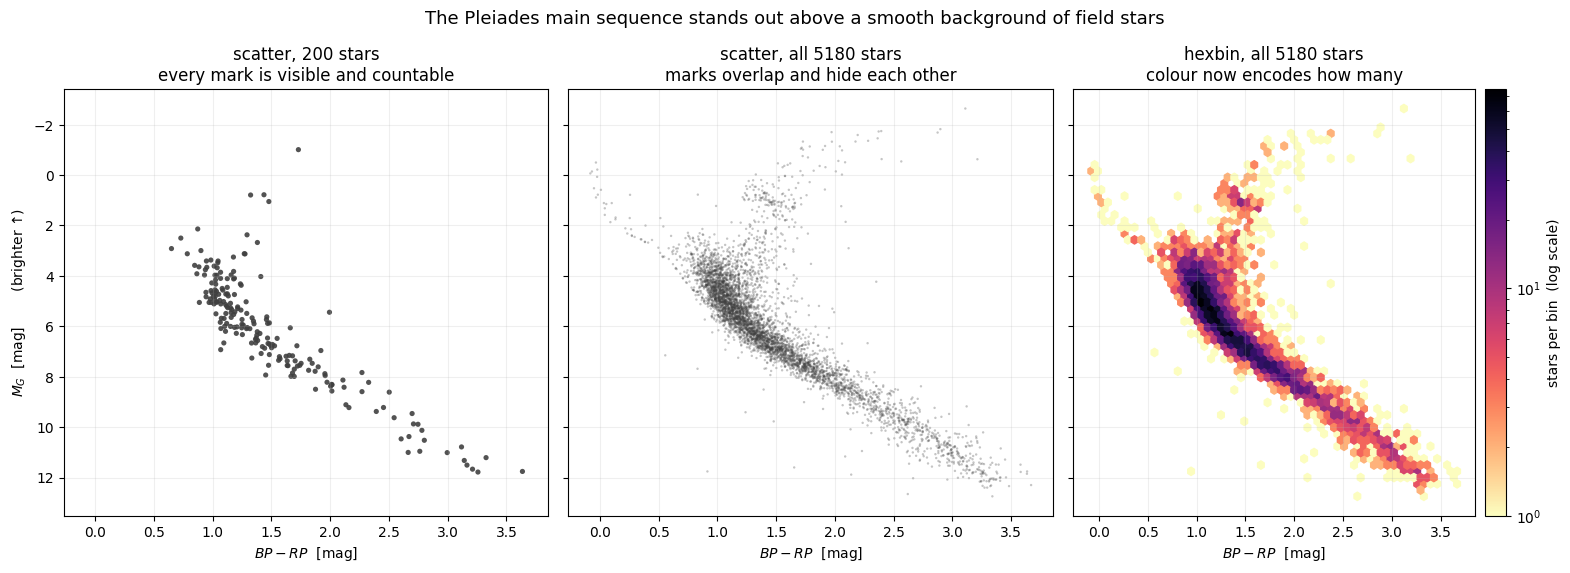

27 of 5180 rows have no colour or no distance, and are dropped here
fullest bin holds 82 stars
67% of occupied bins hold more than one star
so most marks in the middle panel are sitting on top of something


In [7]:
# A thinned sample, to show the encoding working as intended
sub = stars.sample(200, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.8), sharex=True, sharey=True)

# ---------- 1. sparse: one mark really is one star ----------
axes[0].scatter(sub["bp_rp"], sub["M_G"],
                s=14, alpha=0.9, color="0.25", edgecolors="none")
axes[0].set_title(f"scatter, {len(sub)} stars\nevery mark is visible and countable")

# ---------- 2. same encoding, all the data ----------
axes[1].scatter(stars["bp_rp"], stars["M_G"],
                s=3, alpha=0.3, color="0.25", edgecolors="none")
axes[1].set_title(f"scatter, all {len(stars)} stars\nmarks overlap and hide each other")

# ---------- 3. density ----------
hb = axes[2].hexbin(stars["bp_rp"], stars["M_G"],
                    gridsize=55, cmap="magma_r", mincnt=1, bins="log")
axes[2].set_title(f"hexbin, all {len(stars)} stars\ncolour now encodes how many")

axes[0].invert_yaxis()                    # shared axes: inverting one inverts all
axes[0].set_ylabel("$M_G$  [mag]        (brighter ↑)")
for ax in axes:
    ax.set_xlabel("$BP - RP$  [mag]")
    ax.grid(alpha=0.2)

cb = fig.colorbar(hb, ax=axes[2], pad=0.02)
cb.set_label("stars per bin  (log scale)")

fig.suptitle("The Pleiades main sequence stands out above a smooth background of field stars",
             fontsize=13)
plt.tight_layout(); plt.show()

# How much overplotting is actually going on?
# scatter and hexbin skip NaNs silently; histogram2d refuses them, so mask first.
finite = np.isfinite(stars["bp_rp"]) & np.isfinite(stars["M_G"])
print(f"{(~finite).sum()} of {len(stars)} rows have no colour or no distance, and are dropped here")

H, _, _ = np.histogram2d(stars.loc[finite, "bp_rp"], stars.loc[finite, "M_G"], bins=55)
occupied = H > 0
print(f"fullest bin holds {H.max():.0f} stars")
print(f"{100 * (H > 1).sum() / occupied.sum():.0f}% of occupied bins hold more than one star")
print("so most marks in the middle panel are sitting on top of something")

> **Left.** At a few hundred points the encoding is faithful: one mark, one star, nothing
> obscured. Individual objects and outliers remain identifiable.
>
> **Middle.** The same call on the full catalogue. The main sequence is present but its core has
> saturated. Reducing marker size and `alpha` delays this and does not prevent it, because the
> limitation is not the marker: a region containing five stars and a region containing five
> hundred both render as solid ink. The counts printed above quantify the loss.
>
> **Right.** The remedy is a change of encoding rather than a better scatter plot. The plane is
> binned, the occupants of each bin are counted, and **count is mapped to colour**. Position no
> longer competes for the same pixel, so the dense cluster ridge and the diffuse field
> population separate into two distinct features.

### Principle

**A scatter plot represents individuals; a density plot represents a distribution.** The
transition point is set by whether the marks remain separable, not by a fixed number of rows.

An operational test: if a reader could point to a mark and ask which star it is, a scatter plot
is appropriate. If the only accurate answer is "one of several hundred", a density plot is
required.

| Call | Binning | Appropriate when |
|---|---|---|
| `ax.hexbin(x, y)` | hexagonal | general purpose; hexagons tile without the grid artefacts of squares |
| `ax.hist2d(x, y)` | rectangular | bin edges should align with round numbers |
| `sns.kdeplot(x, y)` | smoothed, unbinned | the underlying distribution is smooth and contours are wanted |

Two arguments above are load-bearing. `bins="log"` maps colour to $\log_{10}(\text{count})$,
necessary because the core exceeds the outskirts by orders of magnitude and a linear scale would
render all but the core as blank. `mincnt=1` leaves empty bins unpainted, so white denotes *no
stars* rather than *few stars*.

### Presentation

Encoding determines whether the structure is visible; the following determine whether it is
interpretable, and apply to all three panels:

1. Units on every axis label.
2. A labelled colourbar. An unlabelled colour scale conveys nothing.
3. A title stating the finding rather than the file name.
4. The magnitude axis inverted, per Part 2.

In [8]:
fig.savefig("data/cmd_density.png", dpi=300, bbox_inches="tight")

> **Saving figures.** For anything going into a paper, poster or thesis, save vector
> formats: they stay sharp at any zoom:
>
> ```python
> fig.savefig("cmd.pdf", bbox_inches="tight")           # LaTeX
> fig.savefig("cmd.png", dpi=300, bbox_inches="tight")  # slides
> ```
>
> `bbox_inches="tight"` is the difference between a figure with clipped axis labels and one
> without. It is the single most useful keyword in matplotlib.

---
## Stop point: and the hook

Look back at the vector point diagram in Part 3.

**Every person in this room can see the cluster.** You could circle it with your finger.

But **not one line of code in this notebook knows it is there.** No membership list, no count, no boundary. Only a picture in which the answer is obvious to a human and invisible to the program.

That gap: *I can see it, but my code cannot*, is where machine learning enters astronomy. Not as a buzzword: the Gaia catalogue has **1.8 billion** stars and nobody is going to circle them by finger.

**Notebook 05 draws the boundary.**

---
### Sources

Physics and figure conventions follow Carroll & Ostlie, *An Introduction to Modern Astrophysics*, 2nd ed.: §3.2 (The Magnitude Scale), §3.6 (The Color Index), §8.2 (The Hertzsprung–Russell Diagram), §13.3 (Stellar Clusters).

### If you want to go deeper
- Rougier, *Scientific Visualization: Python + Matplotlib*: the figure-anatomy and coordinate-system chapters · <https://github.com/rougier/scientific-visualization-book>
- Pasha & Agostino, *Intermediate matplotlib: Towards Publication-Ready Plots* · <https://prappleizer.github.io/>
- Matplotlib official cheat sheets · <https://matplotlib.org/cheatsheets/>